# Figure 5 — Where to Plant Under a Budget (BLOCKED)

**Claim (intended)**: for the same amount of new canopy, an exposure-aware strategy
avoids more dose than static strategies (random/temperature-only/population-only/
vulnerability-only/mobility-only vs integrated heat×mobility×vulnerability).

**This entire figure is BLOCKED.** No optimization/strategy-comparison pipeline has ever
been executed for any city. This notebook documents exactly what is missing rather than
fabricating placeholder results.


In [1]:

import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "configs").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "paper_figures"))
import pandas as pd, matplotlib.pyplot as plt
from plotting_utils import set_nature_style, new_panel_fig, label_panel, save_panel, blocked_panel, make_composite, save_source_table
set_nature_style()
FIG_DIR = REPO_ROOT / "figures/paper/main/figure5"; TAB_DIR = REPO_ROOT / "reports/paper_figures/figure5"
FIG_DIR.mkdir(parents=True, exist_ok=True); TAB_DIR.mkdir(parents=True, exist_ok=True)


## Audit — exactly what is missing

In [2]:

checks = []
for city in ["palma_de_mallorca", "bilbao", "sevilla"]:
    p = REPO_ROOT / f"data/{city}/green_mobility/exposure/weekday_full_edges.parquet"
    checks.append({"input": f"{city}: combined edges table (edge_id,length_m,flow_total,flow_active,exposure_score,vulnerability_index,utci_peak_c)",
                   "path": str(p), "exists": p.exists()})
checks.append({"input": "interventions/strategies.py -- ranking functions", "path": "src/green_mobility/interventions/strategies.py", "exists": (REPO_ROOT/"src/green_mobility/interventions/strategies.py").exists()})
checks.append({"input": "vulnerability_index (any city)", "path": "data/*/vulnerability/*.parquet", "exists": len(list((REPO_ROOT/"data").glob("*/vulnerability/*.parquet")))>0})
checks.append({"input": "any executed intervention_comparison.csv (any city)", "path": "results/*/intervention_comparison.csv", "exists": len(list((REPO_ROOT/"results").glob("*/*/intervention_comparison.csv")))>0})
df = pd.DataFrame(checks)
print(df.to_string(index=False))
save_source_table(df, TAB_DIR, "audit")


                                                                                                                           input                                                                                                            path  exists
palma_de_mallorca: combined edges table (edge_id,length_m,flow_total,flow_active,exposure_score,vulnerability_index,utci_peak_c) /home/fbellisardi/code/green_mobility/data/palma_de_mallorca/green_mobility/exposure/weekday_full_edges.parquet   False
           bilbao: combined edges table (edge_id,length_m,flow_total,flow_active,exposure_score,vulnerability_index,utci_peak_c)            /home/fbellisardi/code/green_mobility/data/bilbao/green_mobility/exposure/weekday_full_edges.parquet   False
          sevilla: combined edges table (edge_id,length_m,flow_total,flow_active,exposure_score,vulnerability_index,utci_peak_c)           /home/fbellisardi/code/green_mobility/data/sevilla/green_mobility/exposure/weekday_full_edges.parquet   False
    

## All 4 panels: BLOCKED

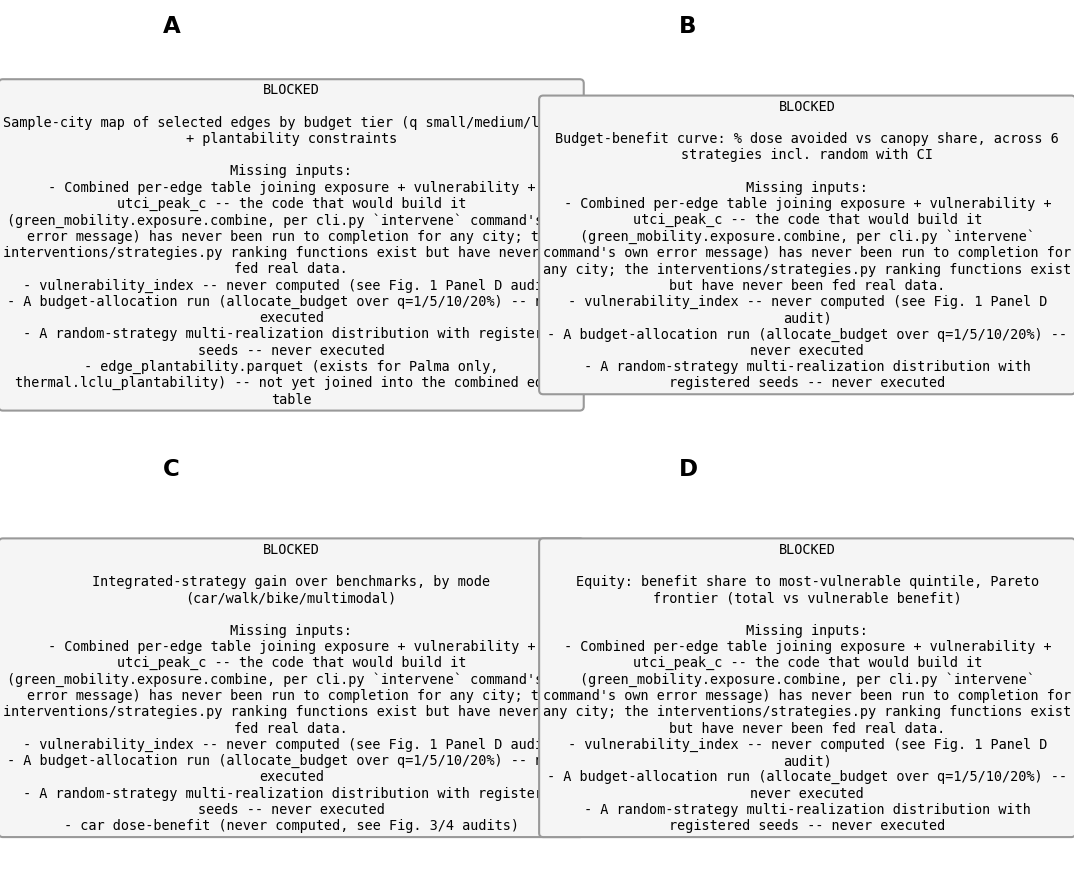

{'figure': 'figure5_canopy_optimization', 'status': 'BLOCKED (all panels)', 'reason': 'no optimization/strategy-comparison pipeline has ever been executed', 'panel_a': {'status': 'BLOCKED'}, 'panel_b': {'status': 'BLOCKED'}, 'panel_c': {'status': 'BLOCKED'}, 'panel_d': {'status': 'BLOCKED'}}


In [3]:

missing_common = [
    "Combined per-edge table joining exposure + vulnerability + utci_peak_c -- the code that "
    "would build it (green_mobility.exposure.combine, per cli.py `intervene` command's own error "
    "message) has never been run to completion for any city; the interventions/strategies.py "
    "ranking functions exist but have never been fed real data.",
    "vulnerability_index -- never computed (see Fig. 1 Panel D audit)",
    "A budget-allocation run (allocate_budget over q=1/5/10/20%) -- never executed",
    "A random-strategy multi-realization distribution with registered seeds -- never executed",
]
panel_specs = [
    ("A", "Sample-city map of selected edges by budget tier (q small/medium/large) + plantability constraints",
     missing_common + ["edge_plantability.parquet (exists for Palma only, thermal.lclu_plantability) -- not yet joined into the combined edges table"]),
    ("B", "Budget-benefit curve: % dose avoided vs canopy share, across 6 strategies incl. random with CI",
     missing_common),
    ("C", "Integrated-strategy gain over benchmarks, by mode (car/walk/bike/multimodal)",
     missing_common + ["car dose-benefit (never computed, see Fig. 3/4 audits)"]),
    ("D", "Equity: benefit share to most-vulnerable quintile, Pareto frontier (total vs vulnerable benefit)",
     missing_common),
]
fig, axes = plt.subplots(2, 2, figsize=(7.0, 6.0))
for ax, (letter, reason, missing) in zip(axes.flatten(), panel_specs):
    blocked_panel(ax, letter, reason, missing)
fig.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "figure5_composite.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figure5_composite.png", bbox_inches="tight", dpi=300)
for ax, (letter, reason, missing) in zip(axes.flatten(), panel_specs):
    single_fig, single_ax = new_panel_fig(3.5, 3.0)
    blocked_panel(single_ax, letter, reason, missing)
    save_panel(single_fig, FIG_DIR, f"panel_{letter.lower()}")
    plt.close(single_fig)
plt.show()

manifest = {"figure": "figure5_canopy_optimization", "status": "BLOCKED (all panels)",
            "reason": "no optimization/strategy-comparison pipeline has ever been executed",
            "panel_a": {"status": "BLOCKED"}, "panel_b": {"status": "BLOCKED"},
            "panel_c": {"status": "BLOCKED"}, "panel_d": {"status": "BLOCKED"}}
(TAB_DIR/"manifest.json").write_text(json.dumps(manifest, indent=2))
print(manifest)
